# Experiment 2 — learning curves (PD)

How AUC scales with the amount of available data (no HPO; LogReg, TabICLv2, TabPFN-v3, and CatBoost). The swept `row_limit` caps the **dataset before the CV split** — train and test shrink together — so the x-axis is the **dataset size**, not the training-set size. Pooled curves in several views, then per-dataset raw points, a data-efficiency table, and a summary of the **AUC trajectory** across the whole sweep. Figures → `figures/experiment2/pd/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.methods.method_config import HPO_METHODS          # tuned methods -> HPO time x n_trials
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, rank_heatmap, hpo_improvement_bars,
    compute_time_bars, runtime_performance_scatter,
    learning_curve, learning_curve_moving_average_with_dots,
    imbalance_curve, imbalance_curve_moving_average_with_dots, per_dataset_sweep_curves,
    sweep_evolution_summary, pd_summary_text, lgd_summary_text,
)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment2/pd')
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment2\pd


In [2]:
df = load_summary(SUMMARY_DIR, experiment='experiment2', task='pd', aggregated=False)
DISPLAY_METHODS = ['LogReg', 'tabicl_v2', 'tabpfn_v3', 'catboost']
missing = sorted(set(DISPLAY_METHODS) - set(df['method']))
if missing:
    print('Missing display methods:', ', '.join(missing))
df = df[df['method'].isin(DISPLAY_METHODS)].copy()
print(f'{df["method"].nunique()} methods, {df["dataset"].nunique()} datasets, '
      f'{df["sweep_value"].nunique()} sweep points')

4 methods, 9 datasets, 1197 sweep points


## 1. AUC vs dataset size ? pooled over datasets

Views of the same curve (one line per method, mean over datasets):
1. **learning curve** with raw sweep points,
2. the same learning curve with a **lower-right inset** zooming the shaded `rows <= 1000` region,
3. **moving average** (trend),
4. **moving average with transparent raw points**.


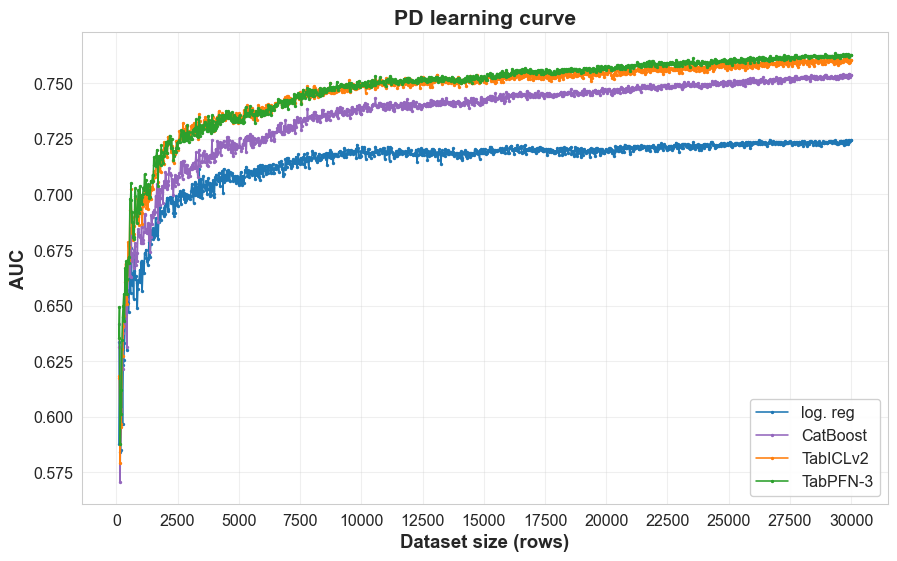

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_learning_curve_auc.pdf')

In [3]:
learning_curve(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)


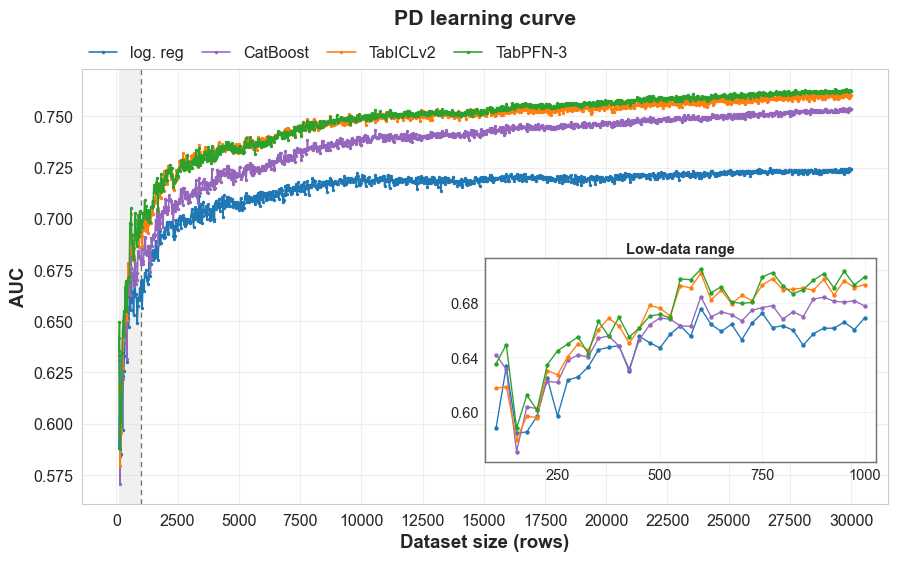

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_learning_curve_auc_zoom.pdf')

In [4]:
learning_curve(df, 'AUC', task_name='PD', zoom=True, out_dir=FIGURES_DIR)


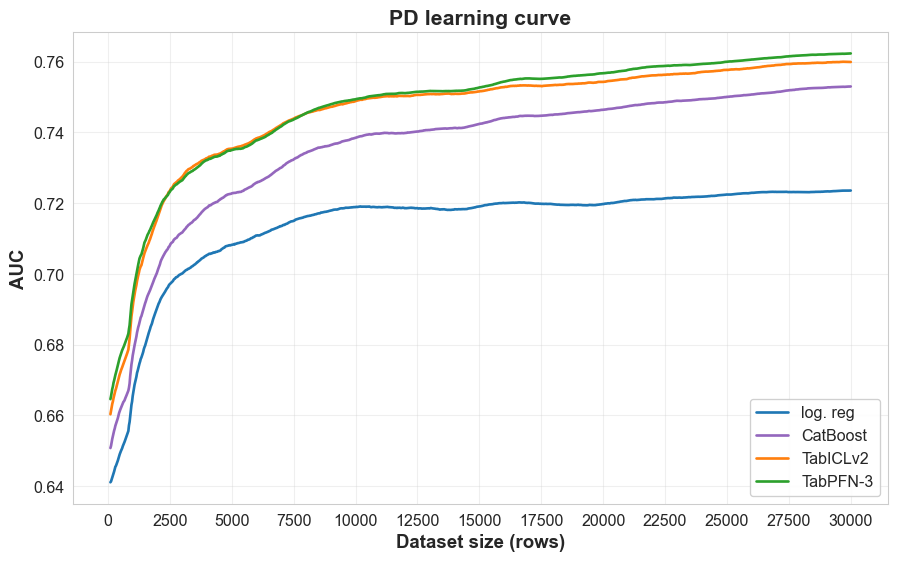

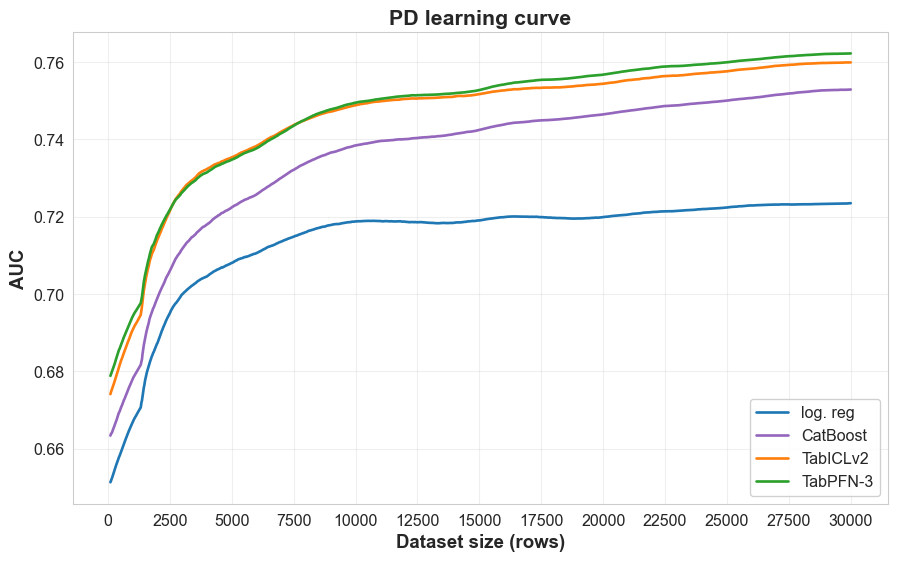

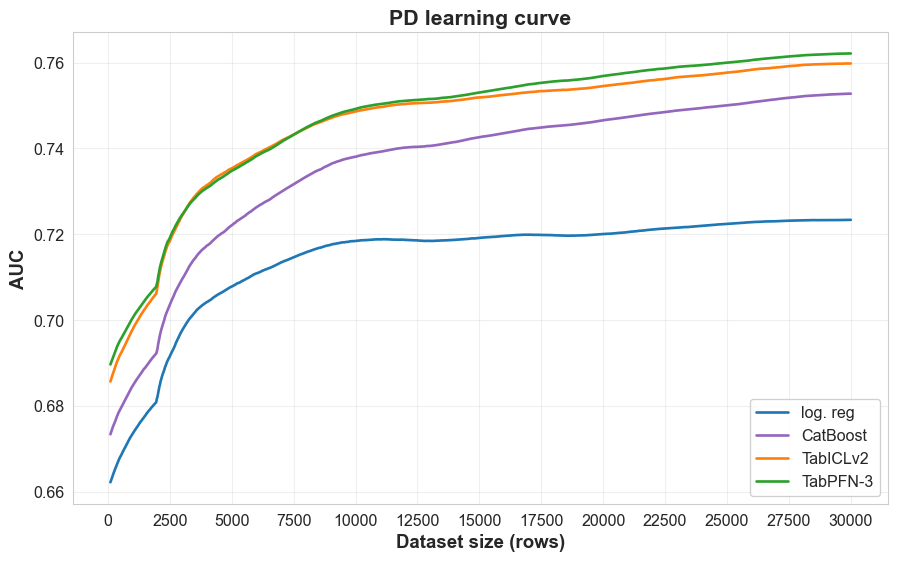

In [5]:
for smooth_window in ('less', 'standard', 'more'):
    learning_curve(df, 'AUC', task_name='PD', smooth=True, smooth_window=smooth_window, out_dir=FIGURES_DIR)


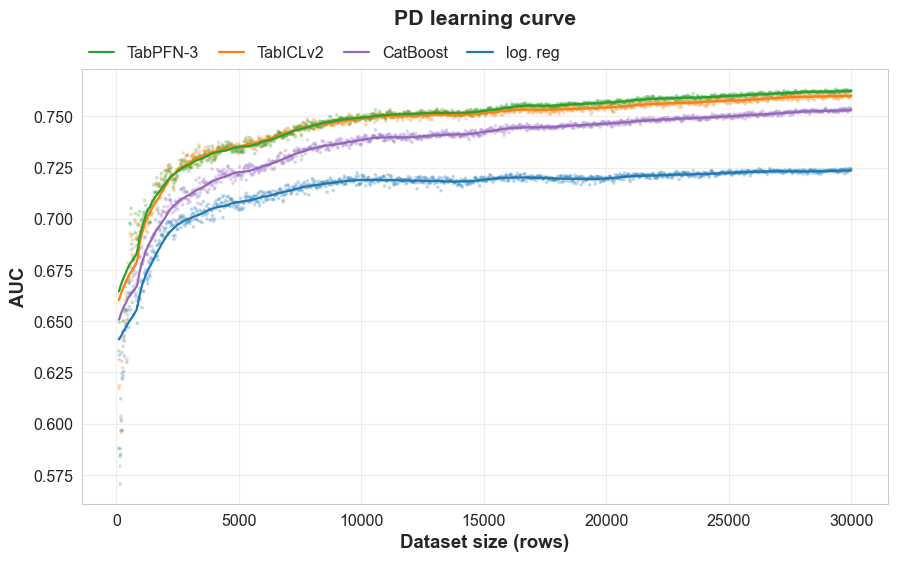

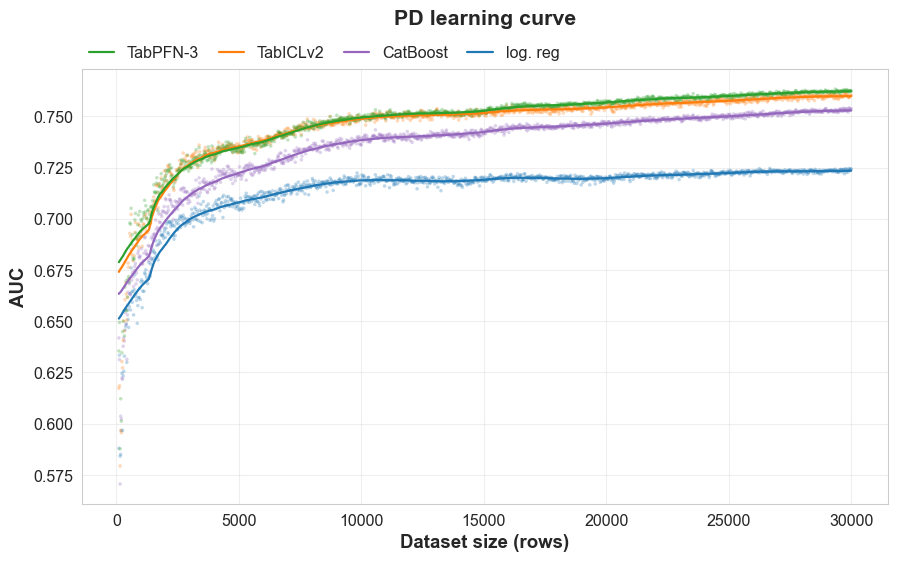

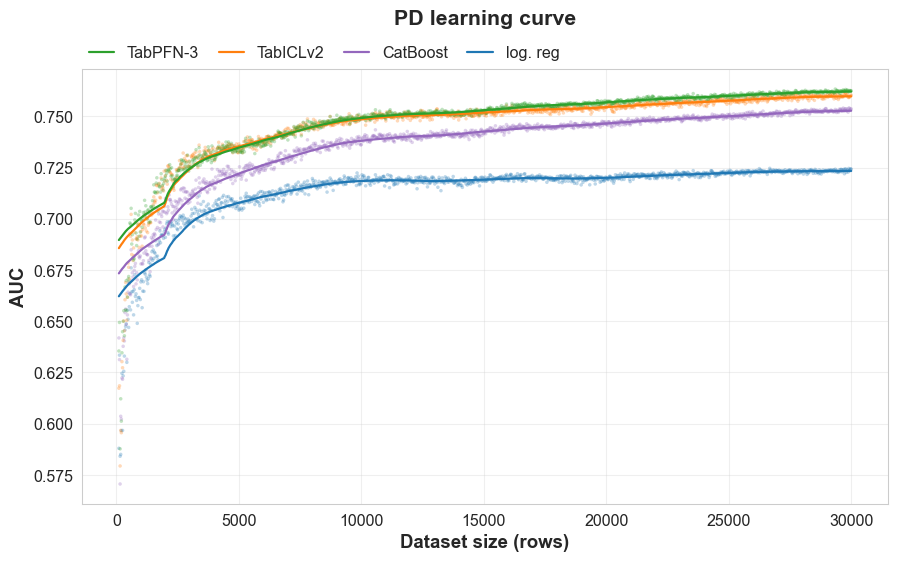

In [6]:
for smooth_window in ('less', 'standard', 'more'):
    learning_curve_moving_average_with_dots(df, 'AUC', task_name='PD', smooth_window=smooth_window, out_dir=FIGURES_DIR)


## 2. AUC per dataset (raw points, all methods)

One plot per dataset so per-dataset behaviour is visible, not only the pooled mean.

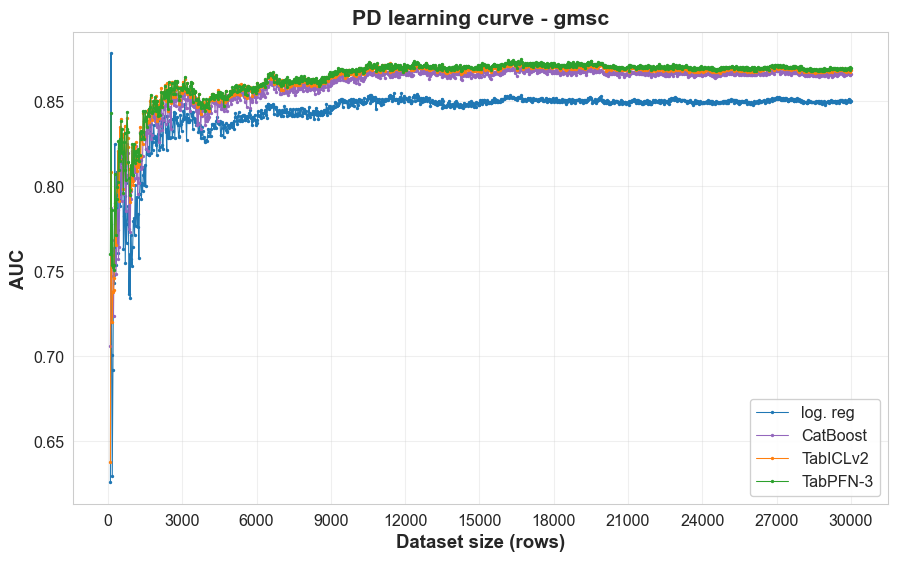

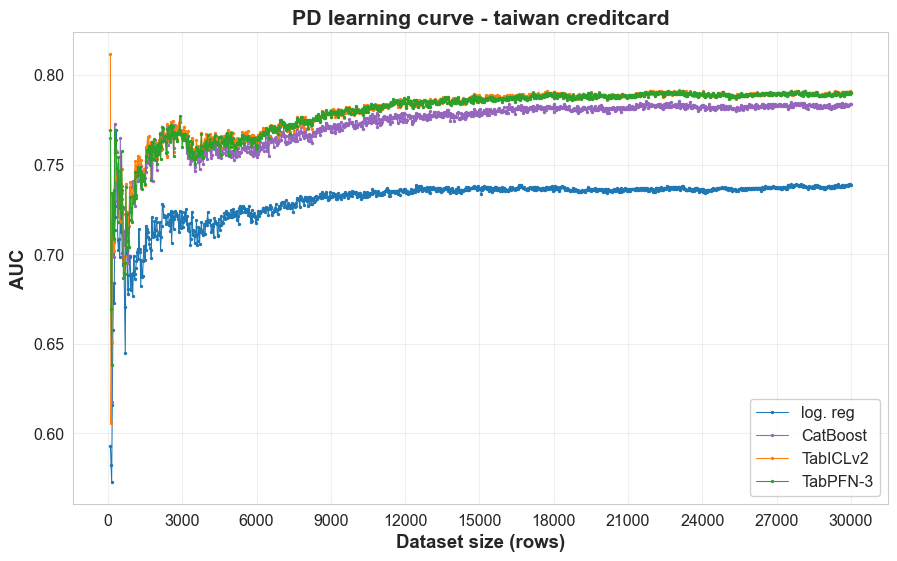

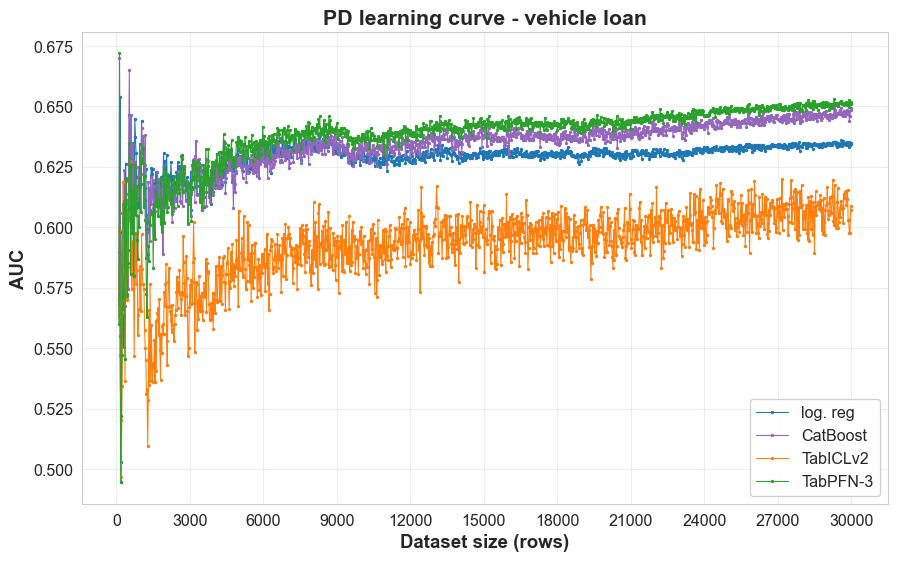

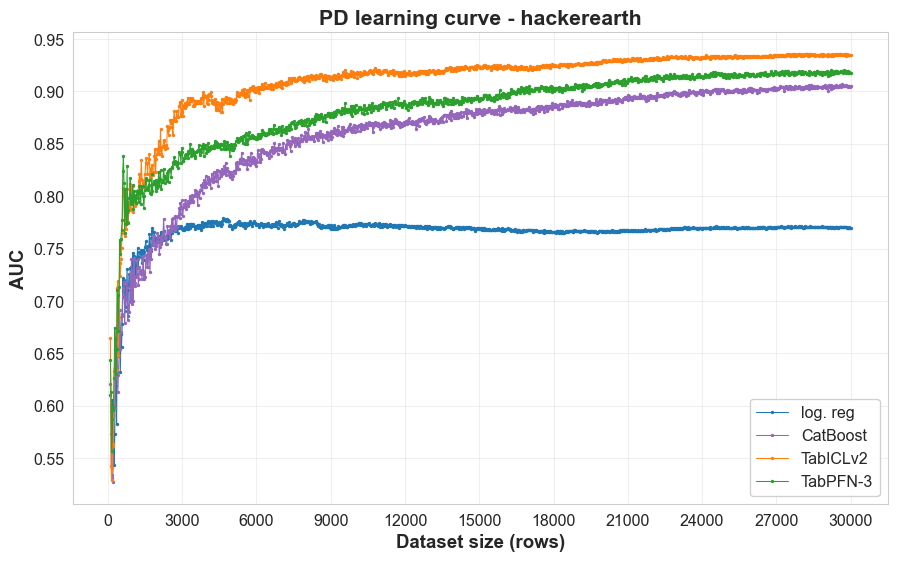

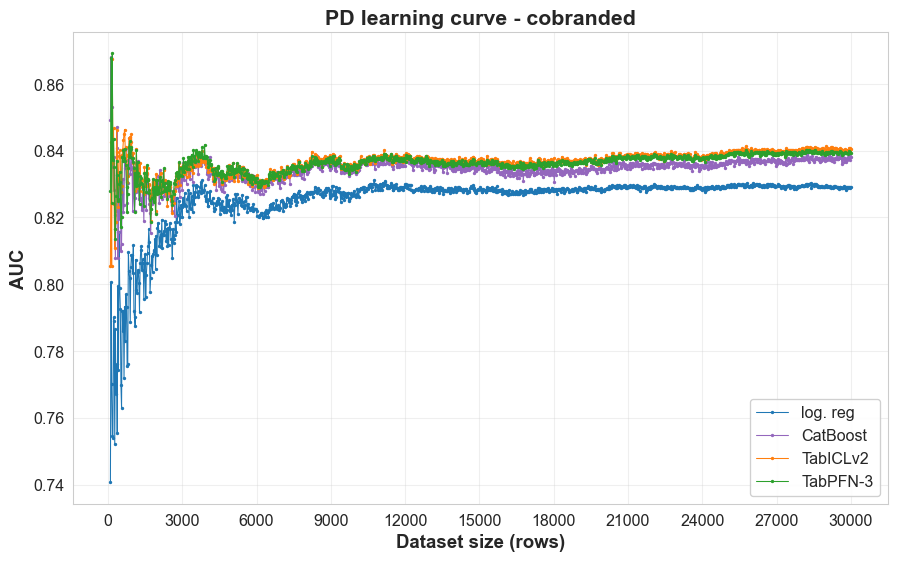

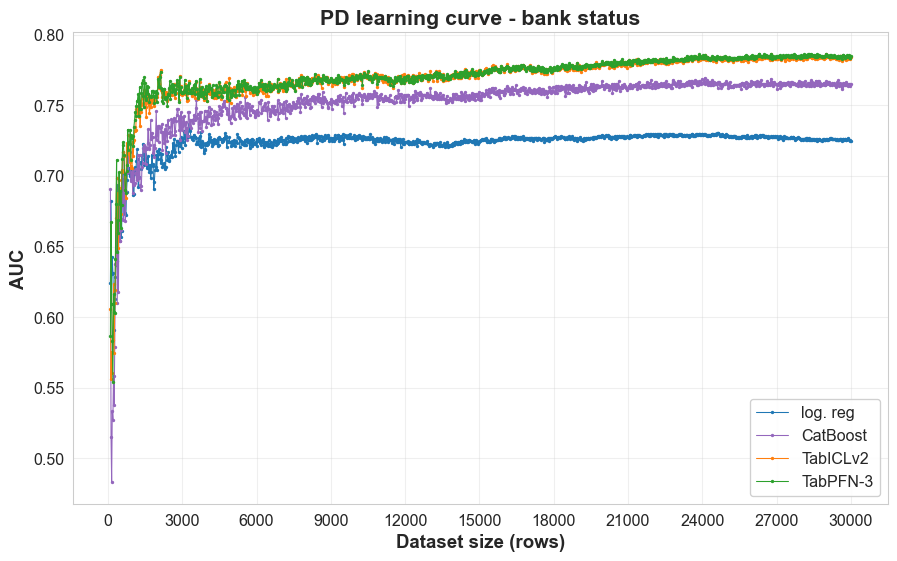

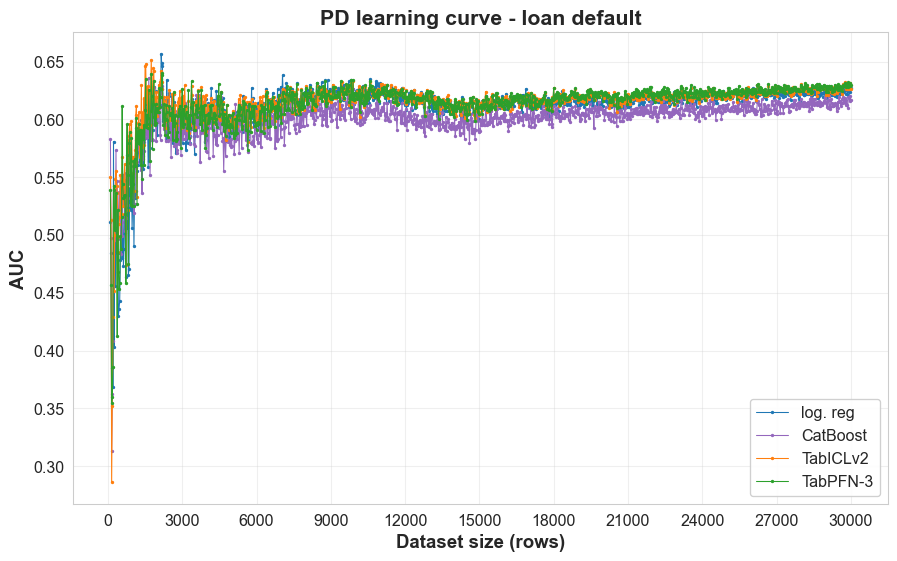

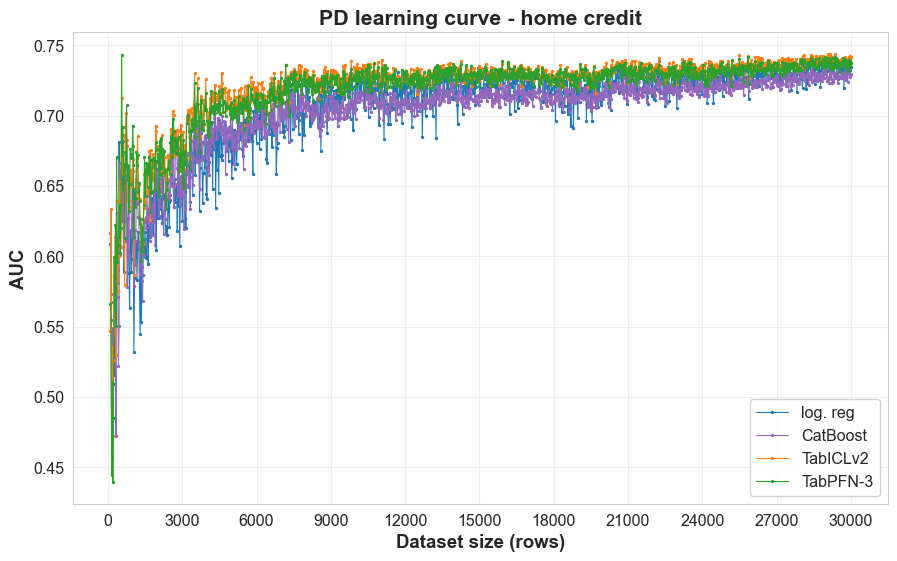

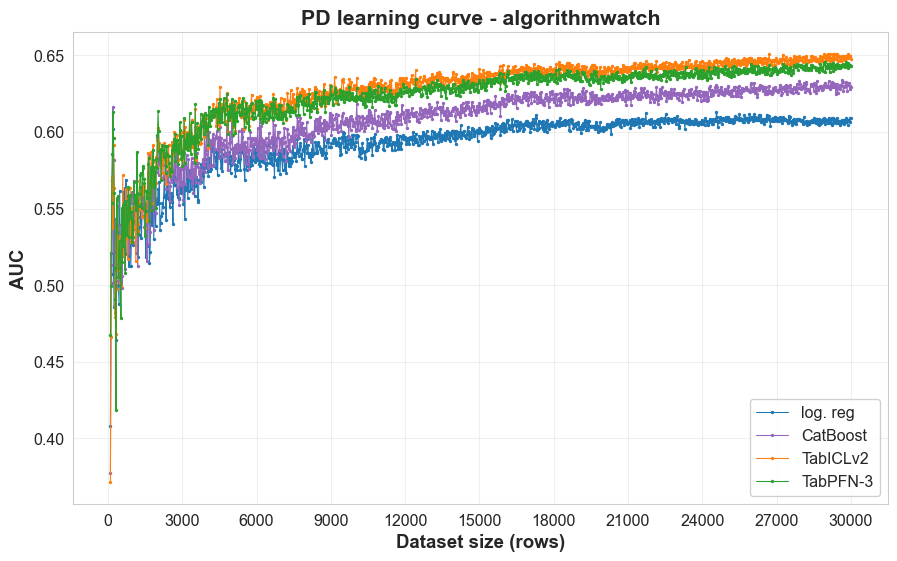

[WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_row_limit_0001_gmsc_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_row_limit_0002_taiwan_creditcard_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_row_limit_0003_vehicle_loan_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_row_limit_0006_hackerearth_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_row_limit_0007_cobranded_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_row_limit_0009_bank_status_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/pd/pd_row_limit_0011_loan_default_auc.pdf'),
 Window

In [7]:
per_dataset_sweep_curves(df, 'AUC', sweep_axis='row_limit', xlabel='Dataset size (rows)', task_name='PD', out_dir=FIGURES_DIR)

## 3. Data efficiency — dataset rows to reach 95% of each method's own plateau

In [8]:
import pandas as _pd
g = df.groupby(['method','sweep_value'])['metric.AUC'].mean().reset_index()
rows = {}
for m, gg in g.groupby('method'):
    gg = gg.sort_values('sweep_value'); target = gg['metric.AUC'].max() * 0.95
    hit = gg[gg['metric.AUC'] >= target]
    rows[m] = int(hit['sweep_value'].iloc[0]) if len(hit) else None
display(_pd.Series(rows, name='dataset rows to reach 95% of own max AUC').sort_values())

LogReg       1600
tabicl_v2    2025
tabpfn_v3    2175
catboost     3250
Name: dataset rows to reach 95% of own max AUC, dtype: int64

## 4. Summary — AUC evolution over dataset size

Mean AUC per method across all datasets at a spread of dataset sizes (not just the largest), so the whole trajectory is visible.

In [9]:
sweep_evolution_summary(df, 'AUC', sweep_axis='row_limit',
                        task_name='Experiment 2 — PD', log_spacing=True, n_points=18)

Experiment 2 — PD — AUC evolution over row_limit  (mean across 9 datasets; 18 of 1197 sweep points; best average first)
sweep_value   100     150     200     275     375     525     750     1050    1475    2050    2875    4000    5600    7850    10975   15325   21450   30000
method                                                                                                                                                     
tabpfn_v3    0.6355  0.5878  0.6013  0.6500  0.6556  0.6691  0.6995  0.6959  0.7088  0.7221  0.7246  0.7291  0.7363  0.7430  0.7495  0.7523  0.7583  0.7625
tabicl_v2    0.6173  0.5794  0.5956  0.6406  0.6689  0.6707  0.6934  0.6866  0.7025  0.7187  0.7279  0.7283  0.7375  0.7442  0.7489  0.7523  0.7551  0.7603
catboost     0.6419  0.5706  0.6023  0.6378  0.6559  0.6683  0.6768  0.6781  0.6900  0.7025  0.7095  0.7146  0.7253  0.7347  0.7388  0.7426  0.7489  0.7537
LogReg       0.5880  0.5841  0.5967  0.6233  0.6475  0.6571  0.6727  0.6566  0.6797  0.6975  0.6982 

"Experiment 2 — PD — AUC evolution over row_limit  (mean across 9 datasets; 18 of 1197 sweep points; best average first)\n======================================================================================================================\nsweep_value   100     150     200     275     375     525     750     1050    1475    2050    2875    4000    5600    7850    10975   15325   21450   30000\nmethod                                                                                                                                                     \ntabpfn_v3    0.6355  0.5878  0.6013  0.6500  0.6556  0.6691  0.6995  0.6959  0.7088  0.7221  0.7246  0.7291  0.7363  0.7430  0.7495  0.7523  0.7583  0.7625\ntabicl_v2    0.6173  0.5794  0.5956  0.6406  0.6689  0.6707  0.6934  0.6866  0.7025  0.7187  0.7279  0.7283  0.7375  0.7442  0.7489  0.7523  0.7551  0.7603\ncatboost     0.6419  0.5706  0.6023  0.6378  0.6559  0.6683  0.6768  0.6781  0.6900  0.7025  0.7095  0.7146  0.7253  0.7347  0.738